In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
import os

# 图表风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

# =============================================================================
# 1. 博弈环境类
# =============================================================================
class MatrixGame:
    def __init__(self, payoff_matrix_row, payoff_matrix_col=None):
        self.row_payoff = np.array(payoff_matrix_row)
        if payoff_matrix_col is None:
            self.col_payoff = -self.row_payoff  # 零和博弈：不需要转置！
        else:
            self.col_payoff = np.array(payoff_matrix_col)
        self.num_row_actions = self.row_payoff.shape[0]
        self.num_col_actions = self.row_payoff.shape[1]
    
    def play(self, row_action, col_action):
        return (self.row_payoff[row_action, col_action],
                self.col_payoff[row_action, col_action])

# =============================================================================
# 2. 算法类
# =============================================================================
class MWU:
    def __init__(self, num_actions, learning_rate, min_prob=1e-6, window_size=None, max_loss=7.0):
        self.num_actions = num_actions
        self.learning_rate = learning_rate
        self.min_prob = min_prob
        self.window_size = window_size
        self.max_loss = max_loss
        
        self.log_weights = np.zeros(num_actions)
        self.recent_losses = []
    
    def get_action(self):
        max_log_weight = np.max(self.log_weights)
        weights = np.exp(self.log_weights - max_log_weight)
        probs = weights / np.sum(weights)
        probs = (1 - self.num_actions * self.min_prob) * probs + self.min_prob
        probs = probs / np.sum(probs)
        return np.random.choice(self.num_actions, p=probs)
    
    def update(self, payoffs):
        losses = self.max_loss - payoffs
        self.recent_losses.append(losses)
        
        if self.window_size is not None and len(self.recent_losses) > self.window_size:
            self.recent_losses.pop(0)
        
        if self.window_size is not None:
            self.log_weights = np.zeros(self.num_actions)
            for l in self.recent_losses:
                self.log_weights -= self.learning_rate * l
        else:
            self.log_weights -= self.learning_rate * losses
    
    def reset(self):
        self.log_weights = np.zeros(self.num_actions)
        self.recent_losses = []

class FixedStrategyPlayer:
    def __init__(self, action, num_actions):
        self.action = action
        self.num_actions = num_actions
    
    def get_action(self):
        return self.action
    
    def update(self, *args):
        pass
    
    def reset(self):
        pass

class HybridMWU:
    def __init__(self, num_actions, gto_ratio, T, exploit_epsilon=0.5, exploit_window=100, max_loss=7.0):
        self.gto_ratio = gto_ratio
        self.gto_player = MWU(num_actions, np.sqrt(2 * np.log(num_actions) / T) / max_loss, 
                              min_prob=1e-6, window_size=None, max_loss=max_loss)
        self.exploit_player = MWU(num_actions, exploit_epsilon, 
                                  min_prob=1e-6, window_size=exploit_window, max_loss=max_loss)
        self.num_actions = num_actions
    
    def get_action(self):
        if np.random.random() < self.gto_ratio:
            return self.gto_player.get_action()
        else:
            return self.exploit_player.get_action()
    
    def update(self, payoffs):
        self.gto_player.update(payoffs)
        self.exploit_player.update(payoffs)
    
    def reset(self):
        self.gto_player.reset()
        self.exploit_player.reset()

# =============================================================================
# 3. 工厂函数
# =============================================================================
def create_gto_mwu(num_actions, T, max_loss=7.0):
    optimal_epsilon = np.sqrt(2 * np.log(num_actions) / T) / max_loss
    return MWU(num_actions, learning_rate=optimal_epsilon, min_prob=1e-6, window_size=None, max_loss=max_loss)

def create_exploitative_mwu(num_actions, epsilon=0.5, window_size=100, max_loss=7.0):
    epsilon = min(epsilon, 5.0)
    return MWU(num_actions, learning_rate=epsilon, min_prob=1e-6, window_size=window_size, max_loss=max_loss)

# =============================================================================
# 4. 并行模拟框架（使用所有64核CPU）
# =============================================================================
def run_single_simulation(args):
    game, player1, player2, T = args
    player1.reset()
    player2.reset()
    
    p1_cumulative = np.zeros(T)
    p2_cumulative = np.zeros(T)
    p1_actions = np.zeros(T, dtype=int)
    p2_actions = np.zeros(T, dtype=int)
    
    p1_total = 0
    p2_total = 0
    
    for t in range(T):
        a1 = player1.get_action()
        a2 = player2.get_action()
        
        p1_payoff, p2_payoff = game.play(a1, a2)
        
        p1_total += p1_payoff
        p2_total += p2_payoff
        p1_cumulative[t] = p1_total
        p2_cumulative[t] = p2_total
        p1_actions[t] = a1
        p2_actions[t] = a2
        
        p1_all_payoffs = game.row_payoff[:, a2]
        p2_all_payoffs = game.col_payoff[a1, :]
        
        player1.update(p1_all_payoffs)
        player2.update(p2_all_payoffs)
    
    return p1_cumulative, p2_cumulative, p1_actions, p2_actions

def run_simulation(game, player1, player2, T, num_runs=100, max_workers=64):
    args_list = [(game, player1, player2, T) for _ in range(num_runs)]
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(run_single_simulation, args_list))
    
    p1_cumulative_payoffs = np.array([r[0] for r in results])
    p2_cumulative_payoffs = np.array([r[1] for r in results])
    p1_action_history = np.array([r[2] for r in results])
    p2_action_history = np.array([r[3] for r in results])
    
    return p1_cumulative_payoffs, p2_cumulative_payoffs, p1_action_history, p2_action_history

# =============================================================================
# 5. 辅助函数（绘图、结果分析）
# =============================================================================
def print_experiment_results(name, p1_payoffs, p2_payoffs):
    final_p1 = p1_payoffs[:, -1]
    final_p2 = p2_payoffs[:, -1]
    
    print(f"\n=== {name} ===")
    print(f"玩家1 最终平均收益: {np.mean(final_p1):.2f} ± {np.std(final_p1):.2f}")
    print(f"玩家2 最终平均收益: {np.mean(final_p2):.2f} ± {np.std(final_p2):.2f}")
    print(f"总平均收益: {np.mean(final_p1 + final_p2):.2f}")

def plot_cumulative_payoffs(p1_payoffs, p2_payoffs, labels, title, save_path=None):
    T = p1_payoffs.shape[1]
    x = np.arange(T)
    
    p1_mean = np.mean(p1_payoffs, axis=0)
    p1_std = np.std(p1_payoffs, axis=0)
    p2_mean = np.mean(p2_payoffs, axis=0)
    p2_std = np.std(p2_payoffs, axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, p1_mean, label=labels[0], linewidth=2)
    plt.fill_between(x, p1_mean - p1_std, p1_mean + p1_std, alpha=0.2)
    plt.plot(x, p2_mean, label=labels[1], linewidth=2)
    plt.fill_between(x, p2_mean - p2_std, p2_mean + p2_std, alpha=0.2)
    
    plt.xlabel('Round')
    plt.ylabel('Cumulative Payoff')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def calculate_average_regret(cumulative_payoffs, p1_action_history, p2_action_history, game, is_row_player=True):
    num_runs, T = cumulative_payoffs.shape
    regret = np.zeros((num_runs, T))
    
    for run in range(num_runs):
        opponent_actions = p2_action_history[run, :] if is_row_player else p1_action_history[run, :]
        
        if is_row_player:
            action_payoffs_per_round = game.row_payoff[:, opponent_actions]
        else:
            action_payoffs_per_round = game.col_payoff[opponent_actions, :].T
        
        action_cumulative_payoffs = np.cumsum(action_payoffs_per_round, axis=1)
        best_in_hindsight_per_t = np.max(action_cumulative_payoffs, axis=0)
        regret[run, :] = (best_in_hindsight_per_t - cumulative_payoffs[run, :]) / np.arange(1, T+1)
    
    return np.mean(regret, axis=0), np.std(regret, axis=0)

def track_action_frequencies(game, player1, player2, T):
    p1_freq = np.zeros((T, game.num_row_actions))
    p2_freq = np.zeros((T, game.num_col_actions))
    
    p1_counts = np.zeros(game.num_row_actions)
    p2_counts = np.zeros(game.num_col_actions)
    
    player1.reset()
    player2.reset()
    
    for t in range(T):
        a1 = player1.get_action()
        a2 = player2.get_action()
        
        p1_counts[a1] += 1
        p2_counts[a2] += 1
        
        p1_freq[t, :] = p1_counts / (t+1)
        p2_freq[t, :] = p2_counts / (t+1)
        
        p1_all_payoffs = game.row_payoff[:, a2]
        p2_all_payoffs = game.col_payoff[a1, :]
        
        player1.update(p1_all_payoffs)
        player2.update(p2_all_payoffs)
    
    return p1_freq, p2_freq

def run_learning_rate_sensitivity(game, epsilons, T=100000, num_runs=20):
    """专门用于GTO vs Exploitative的学习率敏感性分析"""
    avg_payoffs = []
    std_payoffs = []
    
    for epsilon in epsilons:
        print(f"Running Learning Rate ε = {epsilon}...")
        gto_player = create_gto_mwu(game.num_row_actions, T)
        exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=epsilon, window_size=100)
        p1_payoffs, p2_payoffs, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
        avg_p2 = np.mean(p2_payoffs[:, -1])  # 取Exploitative玩家（玩家2）的收益
        std_p2 = np.std(p2_payoffs[:, -1])
        avg_payoffs.append(avg_p2)
        std_payoffs.append(std_p2)
        print(f"Average payoff: {avg_p2:.2f} ± {std_p2:.2f}")
    
    return avg_payoffs, std_payoffs

def plot_sensitivity_curve(param_values, avg_payoffs, std_payoffs, param_name, title, save_path=None):
    plt.figure(figsize=(10, 6))
    plt.errorbar(param_values, avg_payoffs, yerr=std_payoffs, fmt='o-', linewidth=2, capsize=5)
    plt.axhline(y=0, color='black', linestyle='--', label='Nash Equilibrium Payoff')
    plt.xlabel(param_name)
    plt.ylabel('Average Payoff of Exploitative Player')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

print("✅ 所有类和函数定义完成！")

✅ 所有类和函数定义完成！


✅ 博弈场景定义完成！

========== 实验1：对抗固定策略 ==========
Running GTO vs Fixed...
Running Exploitative vs Fixed...
Done!


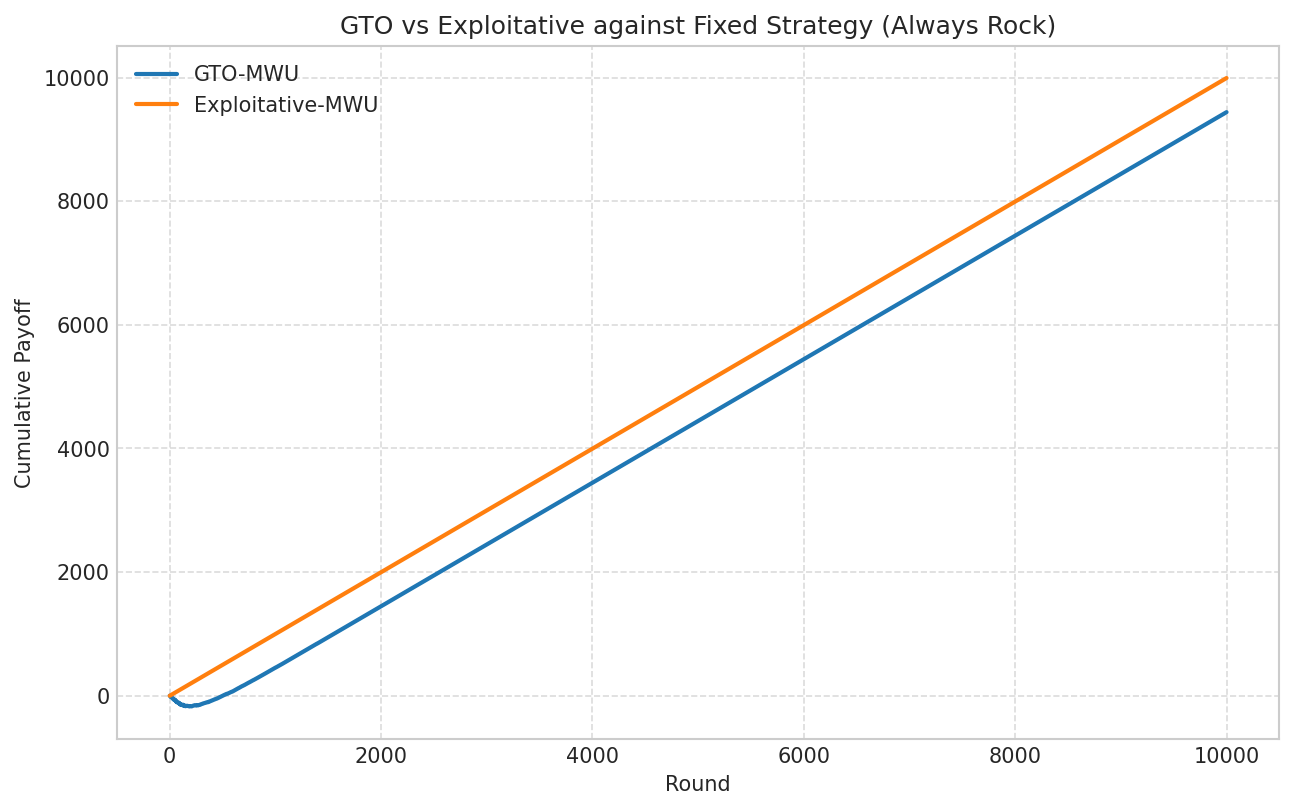

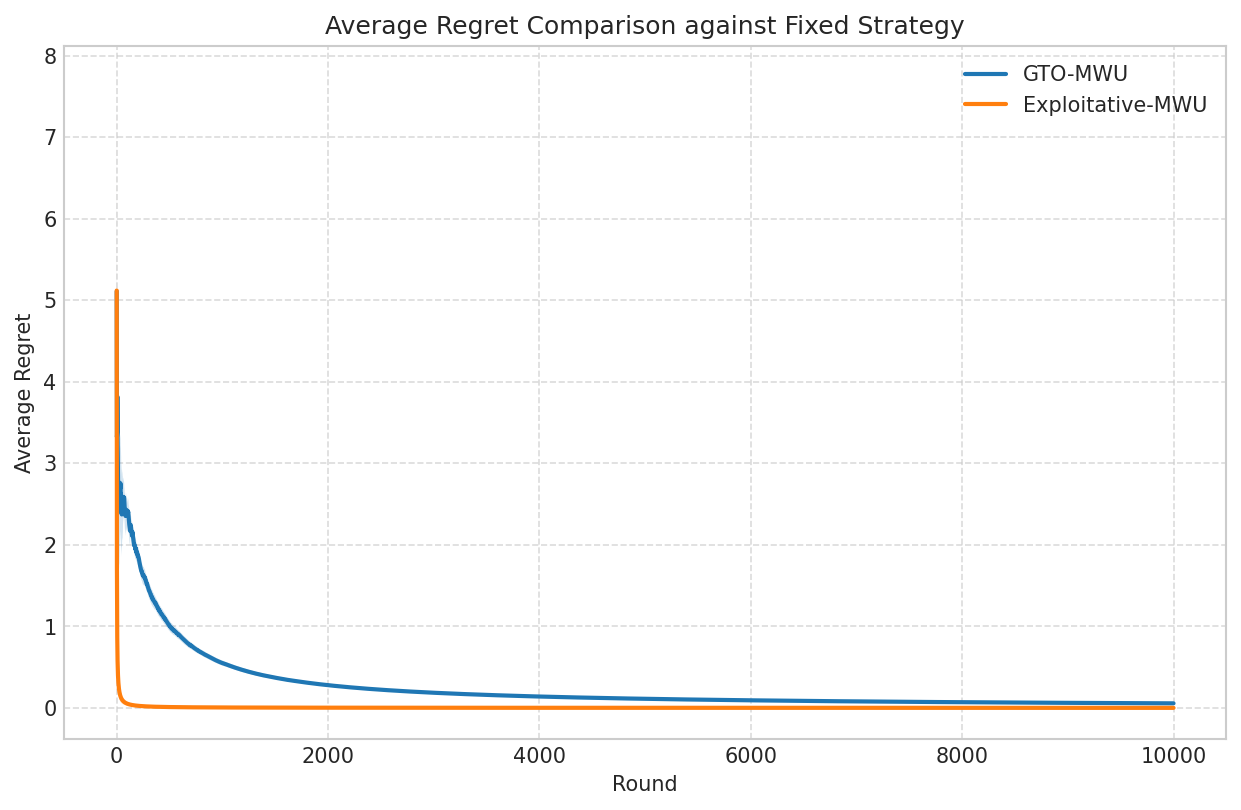


========== 实验2：GTO vs GTO ==========
Running GTO vs GTO...
Done!


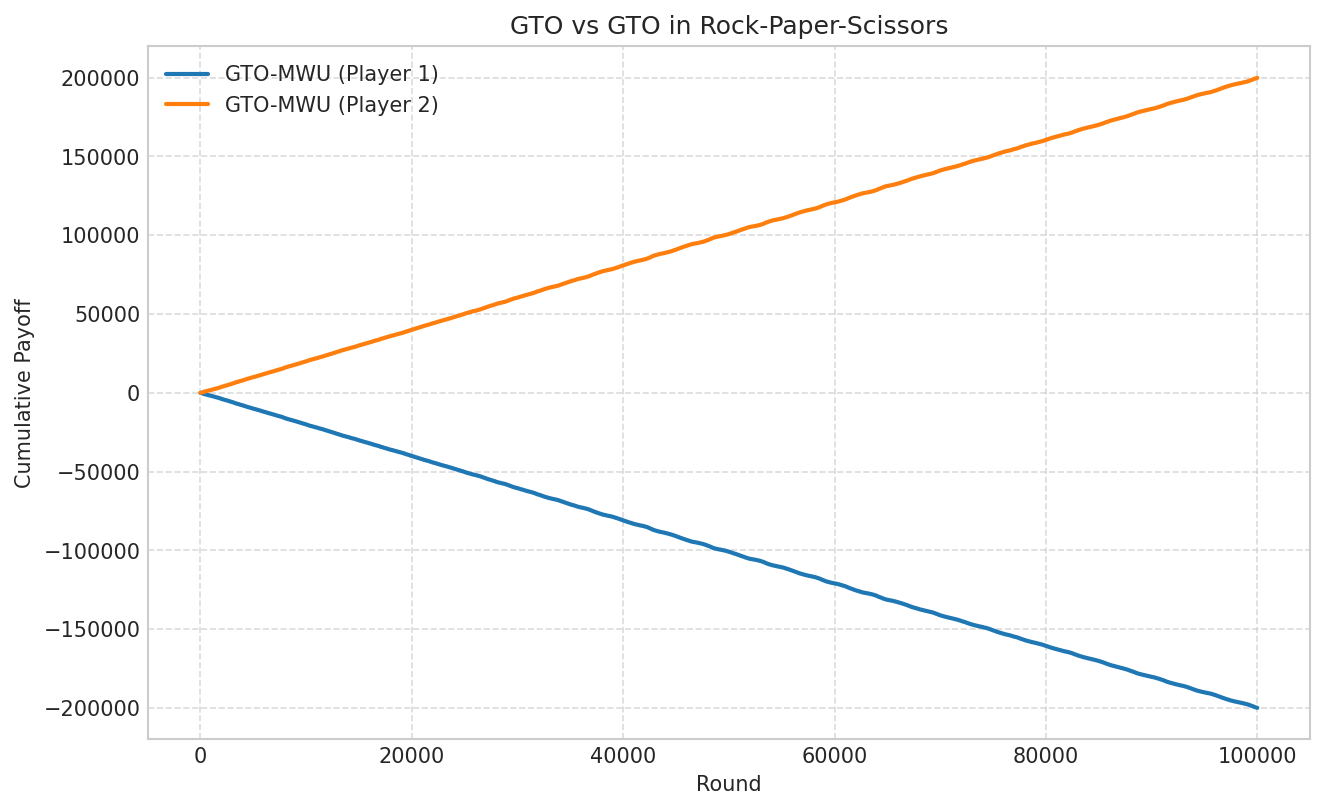

Tracking action frequencies for GTO vs GTO...


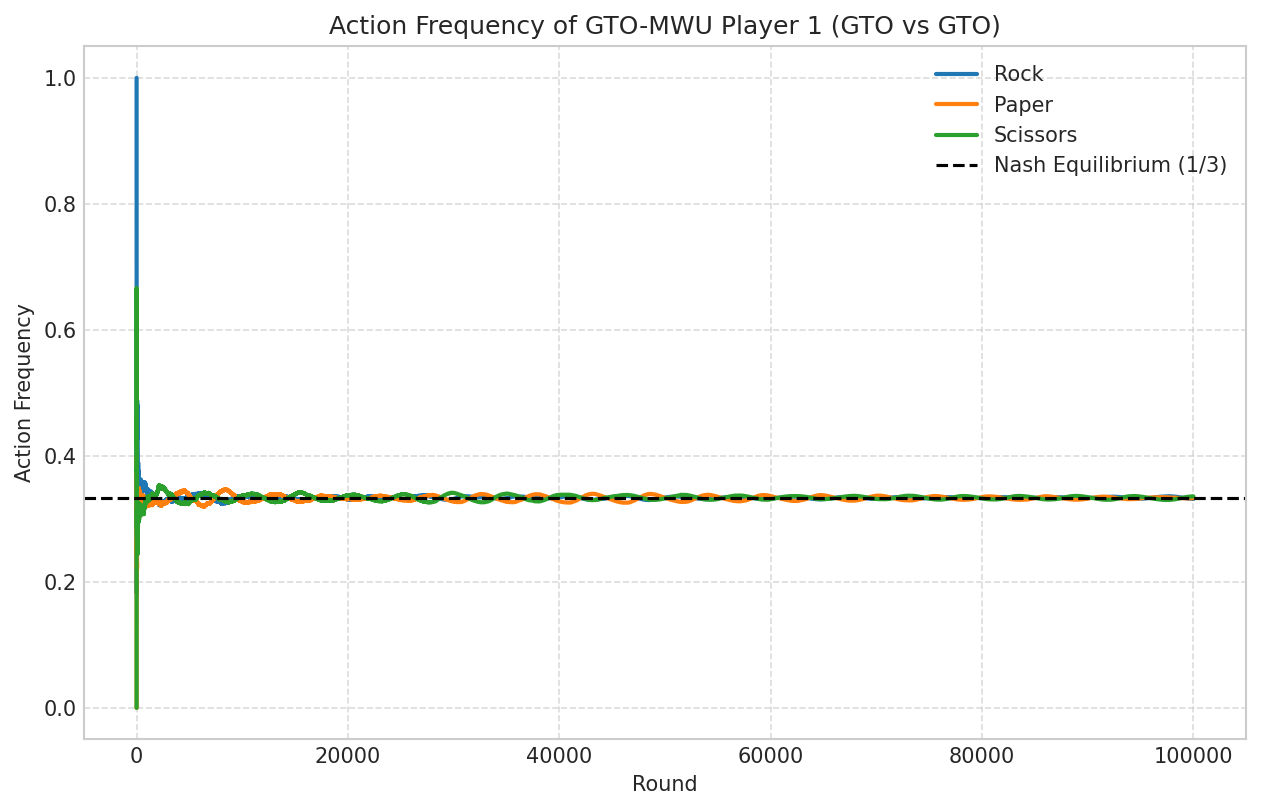


========== 实验3：Exploitative vs Exploitative ==========
Running Exploitative vs Exploitative...
Done!


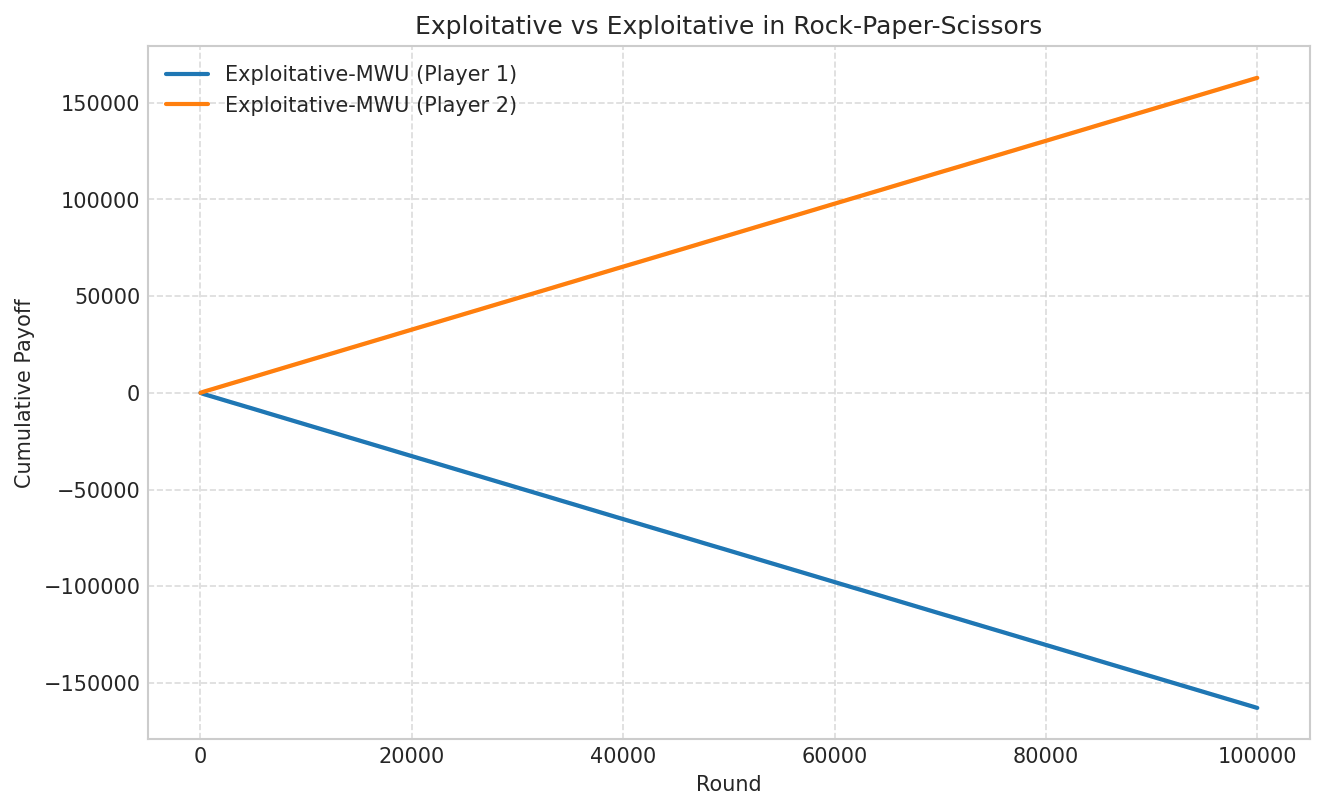

Tracking action frequencies for Exploitative vs Exploitative...


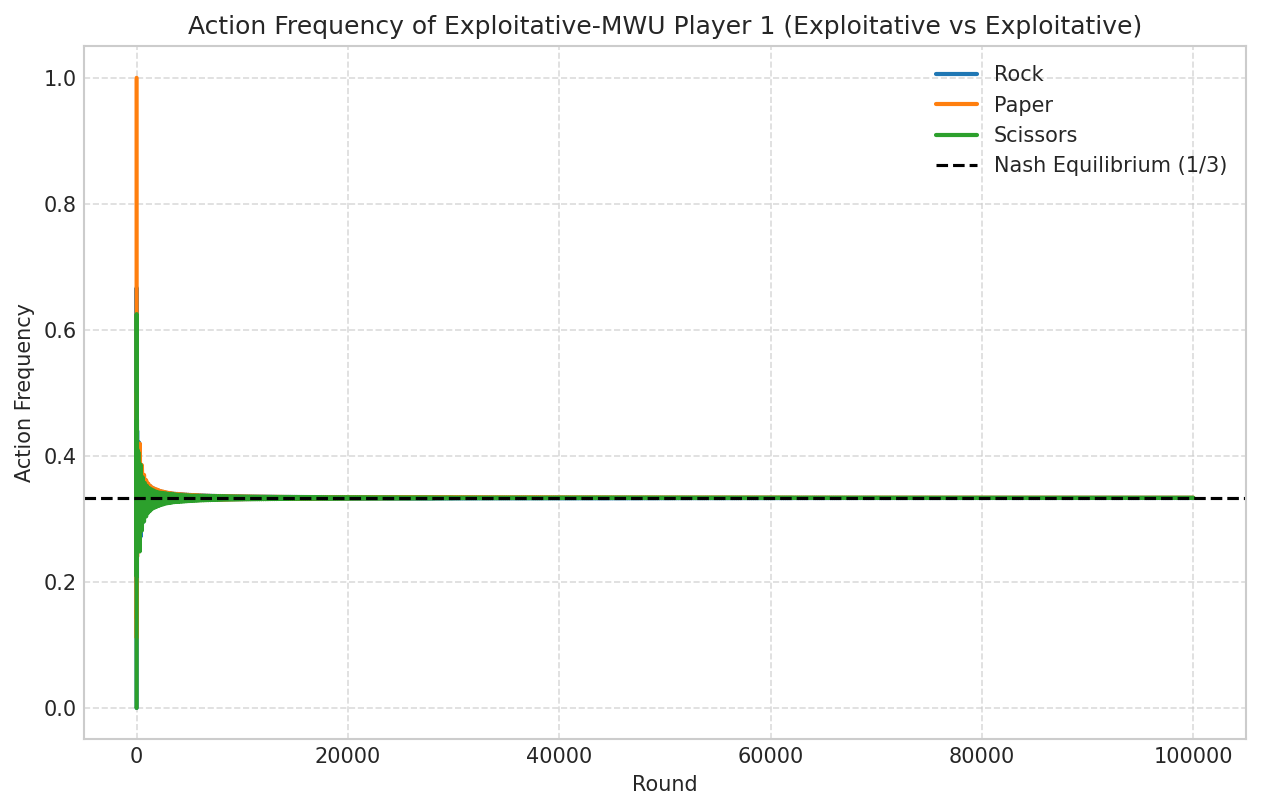


========== 实验4：GTO vs Exploitative ==========
Running GTO vs Exploitative...
Done!


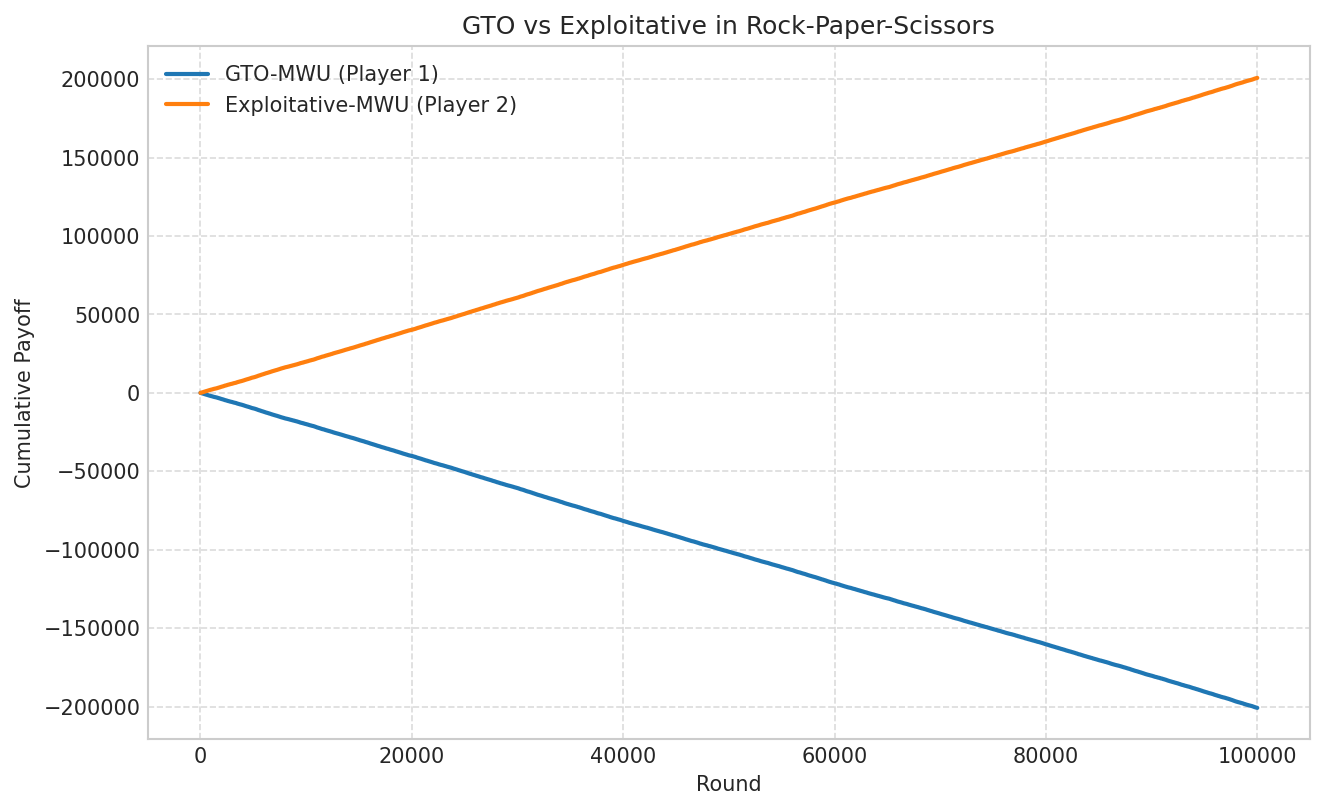


=== GTO vs 固定策略(永远出石头) ===
玩家1 最终平均收益: 9442.31 ± 29.96
玩家2 最终平均收益: 0.00 ± 0.00
总平均收益: 9442.31

=== Exploitative vs 固定策略(永远出石头) ===
玩家1 最终平均收益: 9994.80 ± 2.47
玩家2 最终平均收益: 0.00 ± 0.00
总平均收益: 9994.80

=== GTO vs GTO ===
玩家1 最终平均收益: -199872.00 ± 0.00
玩家2 最终平均收益: 199872.00 ± 0.00
总平均收益: 0.00

=== Exploitative vs Exploitative ===
玩家1 最终平均收益: -162805.00 ± 0.00
玩家2 最终平均收益: 162805.00 ± 0.00
总平均收益: 0.00

=== GTO vs Exploitative ===
玩家1 最终平均收益: -200772.00 ± 0.00
玩家2 最终平均收益: 200772.00 ± 0.00
总平均收益: 0.00

✅ 所有基础实验完成！图表已保存为PNG文件。


In [3]:
# =============================================================================
# 定义博弈场景
# =============================================================================
RPS_PAYOFF = [
    [-6, -1, 1],
    [1, -6, -1],
    [-1, 1, -6]
]
rps_game = MatrixGame(RPS_PAYOFF)

BOS_PAYOFF_ROW = [
    [4, 0],
    [0, 2]
]
BOS_PAYOFF_COL = [
    [2, 0],
    [0, 4]
]
bos_game = MatrixGame(BOS_PAYOFF_ROW, BOS_PAYOFF_COL)

print("✅ 博弈场景定义完成！")

# =============================================================================
# 实验1：对抗固定策略（永远出石头）
# =============================================================================
print("\n========== 实验1：对抗固定策略 ==========")
T = 10000
num_runs = 100
game = rps_game

fixed_player = FixedStrategyPlayer(action=0, num_actions=game.num_col_actions)
gto_player = create_gto_mwu(game.num_row_actions, T)
exploit_player = create_exploitative_mwu(game.num_row_actions, epsilon=1.0, window_size=100)

print("Running GTO vs Fixed...")
gto_vs_fixed, _, gto_vs_fixed_p1_hist, gto_vs_fixed_p2_hist = run_simulation(game, gto_player, fixed_player, T, num_runs)
print("Running Exploitative vs Fixed...")
exploit_vs_fixed, _, exploit_vs_fixed_p1_hist, exploit_vs_fixed_p2_hist = run_simulation(game, exploit_player, fixed_player, T, num_runs)
print("Done!")

# 绘制对比图
plt.figure(figsize=(10, 6))
x = np.arange(T)
gto_mean = np.mean(gto_vs_fixed, axis=0)
gto_std = np.std(gto_vs_fixed, axis=0)
exploit_mean = np.mean(exploit_vs_fixed, axis=0)
exploit_std = np.std(exploit_vs_fixed, axis=0)

plt.plot(x, gto_mean, label='GTO-MWU', linewidth=2)
plt.fill_between(x, gto_mean - gto_std, gto_mean + gto_std, alpha=0.2)
plt.plot(x, exploit_mean, label='Exploitative-MWU', linewidth=2)
plt.fill_between(x, exploit_mean - exploit_std, exploit_mean + exploit_std, alpha=0.2)

plt.xlabel('Round')
plt.ylabel('Cumulative Payoff')
plt.title('GTO vs Exploitative against Fixed Strategy (Always Rock)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('fixed_strategy_comparison.png', bbox_inches='tight')
plt.show()

# 计算并绘制后悔值曲线
gto_regret_mean, gto_regret_std = calculate_average_regret(gto_vs_fixed, gto_vs_fixed_p1_hist, gto_vs_fixed_p2_hist, game, is_row_player=True)
exploit_regret_mean, exploit_regret_std = calculate_average_regret(exploit_vs_fixed, exploit_vs_fixed_p1_hist, exploit_vs_fixed_p2_hist, game, is_row_player=True)

plt.figure(figsize=(10, 6))
plt.plot(x, gto_regret_mean, label='GTO-MWU', linewidth=2)
plt.fill_between(x, gto_regret_mean - gto_regret_std, gto_regret_mean + gto_regret_std, alpha=0.2)
plt.plot(x, exploit_regret_mean, label='Exploitative-MWU', linewidth=2)
plt.fill_between(x, exploit_regret_mean - exploit_regret_std, exploit_regret_mean + exploit_regret_std, alpha=0.2)

plt.xlabel('Round')
plt.ylabel('Average Regret')
plt.title('Average Regret Comparison against Fixed Strategy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('regret_comparison.png', bbox_inches='tight')
plt.show()

# =============================================================================
# 实验2：GTO vs GTO
# =============================================================================
print("\n========== 实验2：GTO vs GTO ==========")
T = 100000
num_runs = 50
game = rps_game

print("Running GTO vs GTO...")
gto1 = create_gto_mwu(game.num_row_actions, T)
gto2 = create_gto_mwu(game.num_col_actions, T)
gto_vs_gto_p1, gto_vs_gto_p2, _, _ = run_simulation(game, gto1, gto2, T, num_runs)
print("Done!")

plot_cumulative_payoffs(
    gto_vs_gto_p1, gto_vs_gto_p2,
    ['GTO-MWU (Player 1)', 'GTO-MWU (Player 2)'],
    'GTO vs GTO in Rock-Paper-Scissors',
    'gto_vs_gto.png'
)

print("Tracking action frequencies for GTO vs GTO...")
gto_p1_freq, gto_p2_freq = track_action_frequencies(game, gto1, gto2, T)

plt.figure(figsize=(10, 6))
x = np.arange(T)
actions = ['Rock', 'Paper', 'Scissors']
for i in range(3):
    plt.plot(x, gto_p1_freq[:, i], label=actions[i], linewidth=2)
plt.axhline(y=1/3, color='black', linestyle='--', label='Nash Equilibrium (1/3)')
plt.xlabel('Round')
plt.ylabel('Action Frequency')
plt.title('Action Frequency of GTO-MWU Player 1 (GTO vs GTO)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('gto_action_frequency.png', bbox_inches='tight')
plt.show()

# =============================================================================
# 实验3：Exploitative vs Exploitative
# =============================================================================
print("\n========== 实验3：Exploitative vs Exploitative ==========")
print("Running Exploitative vs Exploitative...")
exploit1 = create_exploitative_mwu(game.num_row_actions, epsilon=0.5, window_size=100)
exploit2 = create_exploitative_mwu(game.num_col_actions, epsilon=0.5, window_size=100)
exploit_vs_exploit_p1, exploit_vs_exploit_p2, _, _ = run_simulation(game, exploit1, exploit2, T, num_runs)
print("Done!")

plot_cumulative_payoffs(
    exploit_vs_exploit_p1, exploit_vs_exploit_p2,
    ['Exploitative-MWU (Player 1)', 'Exploitative-MWU (Player 2)'],
    'Exploitative vs Exploitative in Rock-Paper-Scissors',
    'exploit_vs_exploit.png'
)

print("Tracking action frequencies for Exploitative vs Exploitative...")
exploit_p1_freq, exploit_p2_freq = track_action_frequencies(game, exploit1, exploit2, T)

plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(x, exploit_p1_freq[:, i], label=actions[i], linewidth=2)
plt.axhline(y=1/3, color='black', linestyle='--', label='Nash Equilibrium (1/3)')
plt.xlabel('Round')
plt.ylabel('Action Frequency')
plt.title('Action Frequency of Exploitative-MWU Player 1 (Exploitative vs Exploitative)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('exploitative_action_frequency.png', bbox_inches='tight')
plt.show()

# =============================================================================
# 实验4：GTO vs Exploitative（关键实验）
# =============================================================================
print("\n========== 实验4：GTO vs Exploitative ==========")
print("Running GTO vs Exploitative...")
gto_player = create_gto_mwu(game.num_row_actions, T)
exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=1.0, window_size=100)
gto_vs_exploit_p1, gto_vs_exploit_p2, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
print("Done!")

plot_cumulative_payoffs(
    gto_vs_exploit_p1, gto_vs_exploit_p2,
    ['GTO-MWU (Player 1)', 'Exploitative-MWU (Player 2)'],
    'GTO vs Exploitative in Rock-Paper-Scissors',
    'gto_vs_exploitative.png'
)

# =============================================================================
# 打印所有实验结果
# =============================================================================
print_experiment_results("GTO vs 固定策略(永远出石头)", gto_vs_fixed, np.zeros_like(gto_vs_fixed))
print_experiment_results("Exploitative vs 固定策略(永远出石头)", exploit_vs_fixed, np.zeros_like(exploit_vs_fixed))
print_experiment_results("GTO vs GTO", gto_vs_gto_p1, gto_vs_gto_p2)
print_experiment_results("Exploitative vs Exploitative", exploit_vs_exploit_p1, exploit_vs_exploit_p2)
print_experiment_results("GTO vs Exploitative", gto_vs_exploit_p1, gto_vs_exploit_p2)

print("\n✅ 所有基础实验完成！图表已保存为PNG文件。")

In [5]:
# =============================================================================
# 定义博弈场景
# =============================================================================
RPS_PAYOFF = [
    [-6, -1, 1],
    [1, -6, -1],
    [-1, 1, -6]
]
rps_game = MatrixGame(RPS_PAYOFF)

BOS_PAYOFF_ROW = [
    [4, 0],
    [0, 2]
]
BOS_PAYOFF_COL = [
    [2, 0],
    [0, 4]
]
bos_game = MatrixGame(BOS_PAYOFF_ROW, BOS_PAYOFF_COL)

print("✅ 博弈场景定义完成！")

✅ 博弈场景定义完成！



========== 高级实验1：学习率敏感性分析 ==========
Running Learning Rate ε = 0.001...
Average payoff: 201307.00 ± 0.00
Running Learning Rate ε = 0.005...
Average payoff: 200976.00 ± 0.00
Running Learning Rate ε = 0.01...
Average payoff: 201543.00 ± 0.00
Running Learning Rate ε = 0.05...
Average payoff: 199568.00 ± 0.00
Running Learning Rate ε = 0.1...
Average payoff: 199928.00 ± 0.00
Running Learning Rate ε = 0.5...
Average payoff: 200399.00 ± 0.00
Running Learning Rate ε = 1.0...
Average payoff: 199318.00 ± 0.00
Running Learning Rate ε = 2.0...
Average payoff: 199377.00 ± 0.00
Running Learning Rate ε = 5.0...
Average payoff: 199627.00 ± 0.00


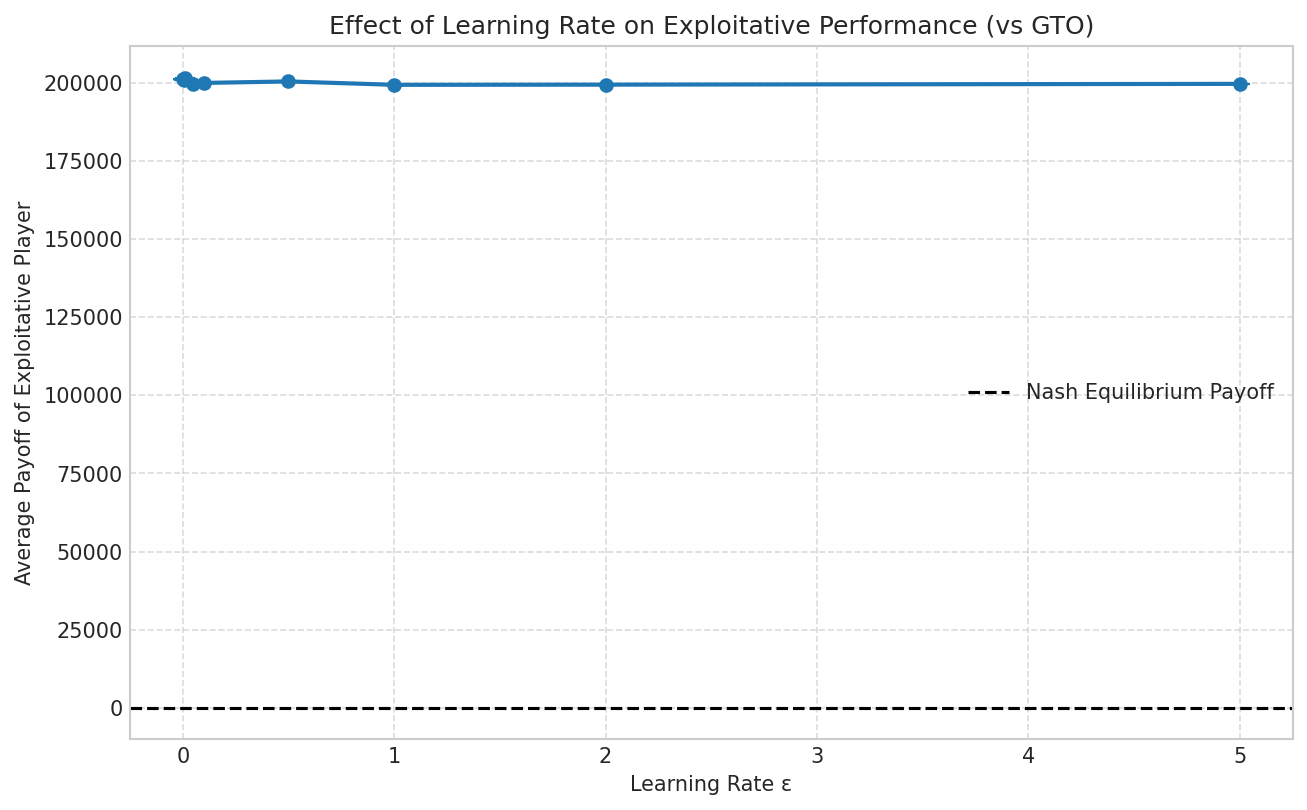


最优学习率: 0.01
最优平均收益: 201543.00 ± 0.00

========== 高级实验2：窗口大小敏感性分析 ==========
Running Window Size = 10...
Average payoff: 201317.00 ± 0.00
Running Window Size = 20...
Average payoff: 200823.00 ± 0.00
Running Window Size = 50...
Average payoff: 201525.00 ± 0.00
Running Window Size = 100...
Average payoff: 201543.00 ± 0.00
Running Window Size = 200...
Average payoff: 202337.00 ± 0.00
Running Window Size = 500...
Average payoff: 200046.00 ± 0.00
Running Window Size = 1000...
Average payoff: 201379.00 ± 0.00
Running Window Size = 2000...
Average payoff: 199691.00 ± 0.00


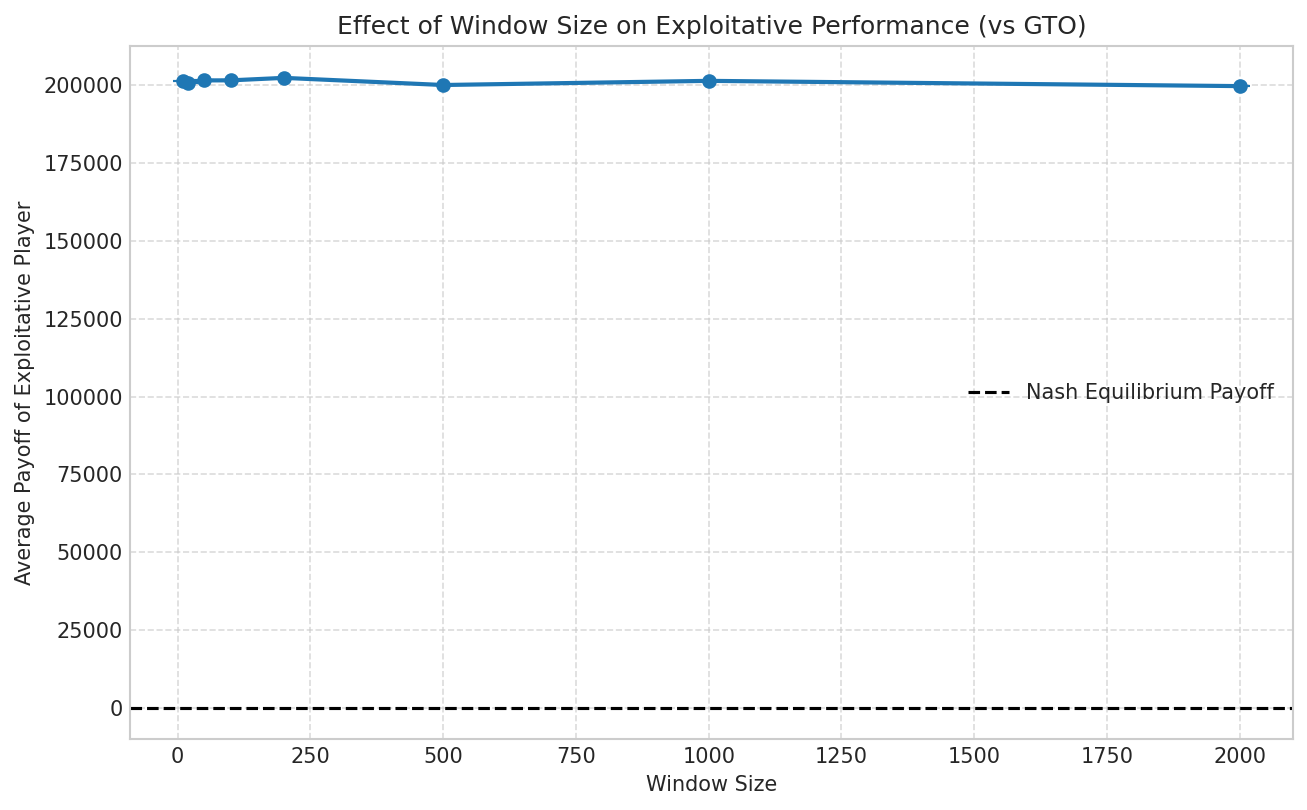


最优窗口大小: 200
最优平均收益: 202337.00 ± 0.00

========== 高级实验3：长期结果验证（100万轮） ==========
Running GTO vs Exploitative (1,000,000 rounds)...
使用最优参数：学习率=0.01, 窗口大小=200
Done!


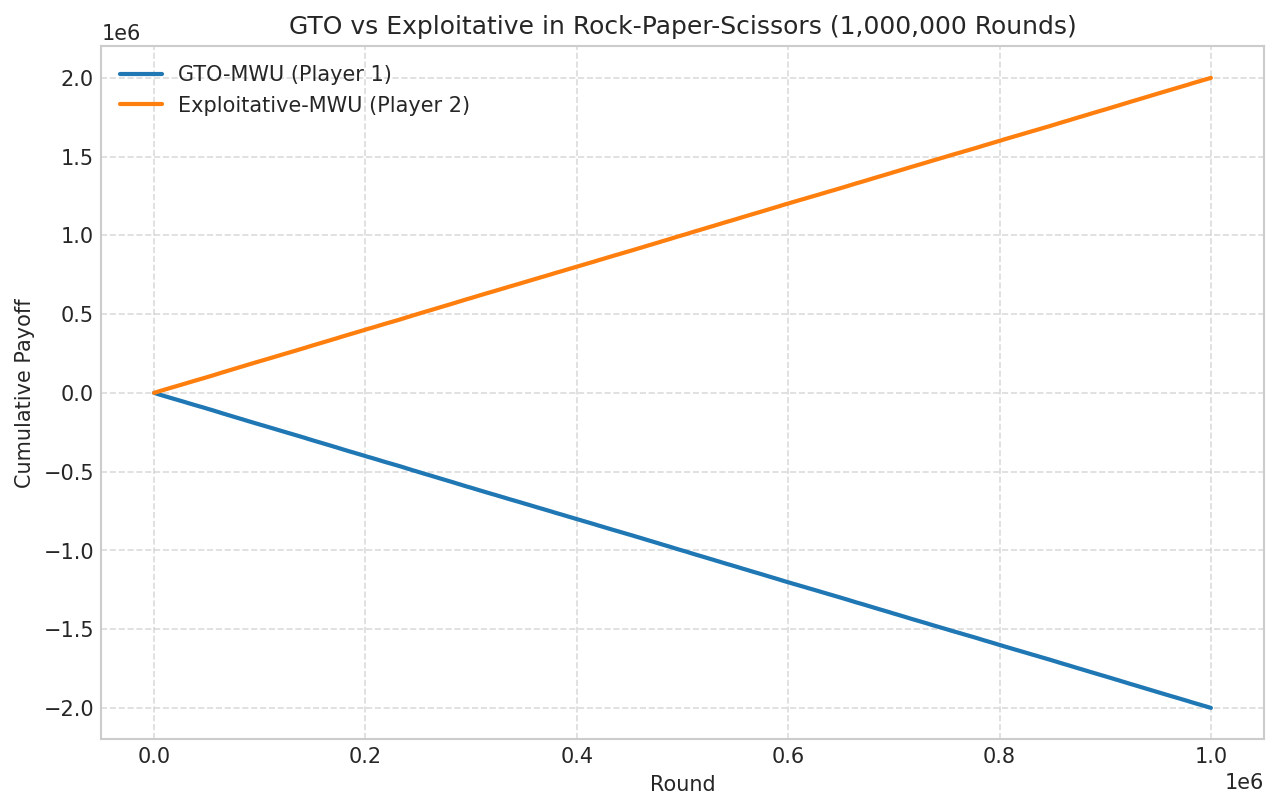


每10万轮的平均收益：
第1个10万轮：GTO -200877.00, Exploitative 200877.00
第2个10万轮：GTO -200469.00, Exploitative 200469.00
第3个10万轮：GTO -200878.00, Exploitative 200878.00
第4个10万轮：GTO -198937.00, Exploitative 198937.00
第5个10万轮：GTO -199875.00, Exploitative 199875.00
第6个10万轮：GTO -201034.00, Exploitative 201034.00
第7个10万轮：GTO -198870.00, Exploitative 198870.00
第8个10万轮：GTO -198806.00, Exploitative 198806.00
第9个10万轮：GTO -199188.00, Exploitative 199188.00
第10个10万轮：GTO -200471.00, Exploitative 200471.00

========== 高级实验4：混合策略最优比例研究 ==========

Testing against Fixed Strategy (Always Rock)...
GTO ratio = 0.0...
Average payoff: 96204.00 ± 0.00
GTO ratio = 0.1...
Average payoff: 96335.00 ± 0.00
GTO ratio = 0.3...
Average payoff: 96736.00 ± 0.00
GTO ratio = 0.5...
Average payoff: 97149.00 ± 0.00
GTO ratio = 0.7...
Average payoff: 97640.00 ± 0.00
GTO ratio = 0.9...
Average payoff: 98161.00 ± 0.00
GTO ratio = 0.95...
Average payoff: 98210.00 ± 0.00
GTO ratio = 1.0...
Average payoff: 98286.00 ± 0.00

Testing against G

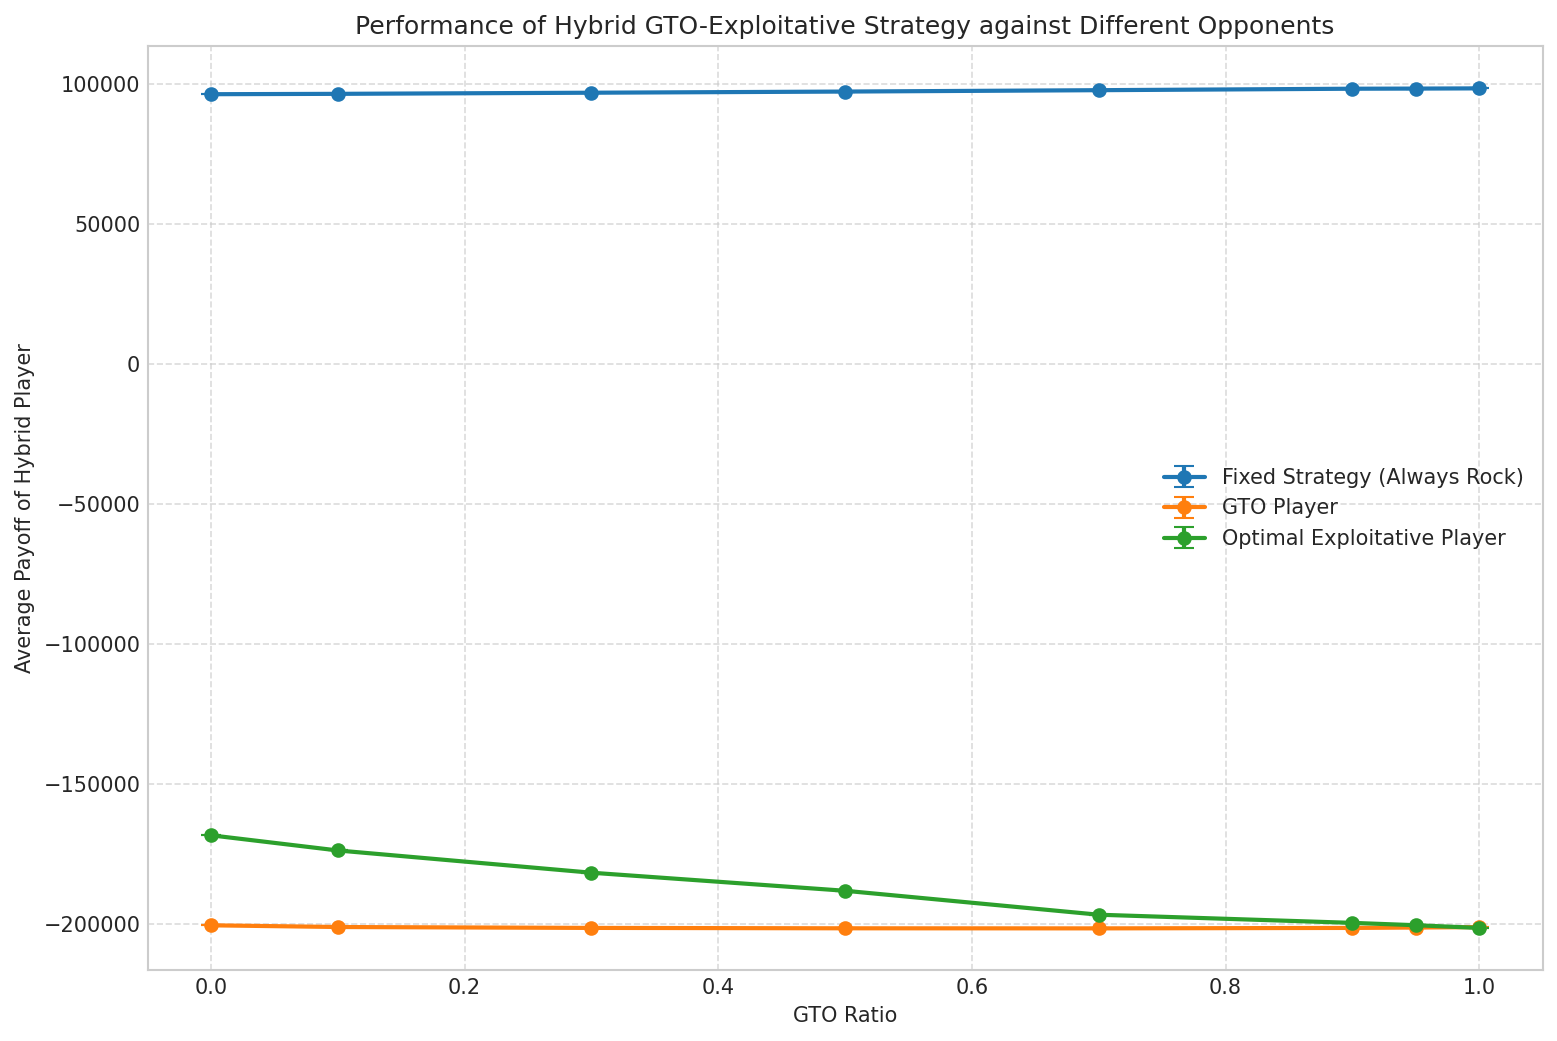


综合最优GTO比例: 0.0
综合平均收益: -90807.67

✅ 所有高级实验完成！


In [6]:
# =============================================================================
# 高级实验1：学习率敏感性分析（修复版）
# =============================================================================
print("\n========== 高级实验1：学习率敏感性分析 ==========")
T = 100000
num_runs = 20
game = rps_game

def run_learning_rate_sensitivity(game, epsilons, T=100000, num_runs=20):
    """专门用于GTO vs Exploitative的学习率敏感性分析（角色正确）"""
    avg_payoffs = []
    std_payoffs = []
    
    for epsilon in epsilons:
        print(f"Running Learning Rate ε = {epsilon}...")
        gto_player = create_gto_mwu(game.num_row_actions, T)
        exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=epsilon, window_size=100)
        p1_payoffs, p2_payoffs, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
        avg_p2 = np.mean(p2_payoffs[:, -1])  # 取Exploitative玩家（玩家2）的收益
        std_p2 = np.std(p2_payoffs[:, -1])
        avg_payoffs.append(avg_p2)
        std_payoffs.append(std_p2)
        print(f"Average payoff: {avg_p2:.2f} ± {std_p2:.2f}")
    
    return avg_payoffs, std_payoffs

# 测试的学习率范围（去掉10.0，太大了没用）
epsilons = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

epsilon_avg, epsilon_std = run_learning_rate_sensitivity(game, epsilons, T, num_runs)

# 绘制结果
plt.figure(figsize=(10, 6))
plt.errorbar(epsilons, epsilon_avg, yerr=epsilon_std, fmt='o-', linewidth=2, capsize=5)
plt.axhline(y=0, color='black', linestyle='--', label='Nash Equilibrium Payoff')
plt.xlabel('Learning Rate ε')
plt.ylabel('Average Payoff of Exploitative Player')
plt.title('Effect of Learning Rate on Exploitative Performance (vs GTO)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('learning_rate_sensitivity.png', bbox_inches='tight')
plt.show()

# 找到最优学习率
optimal_idx = np.argmax(epsilon_avg)
optimal_epsilon = epsilons[optimal_idx]
print(f"\n最优学习率: {optimal_epsilon}")
print(f"最优平均收益: {epsilon_avg[optimal_idx]:.2f} ± {epsilon_std[optimal_idx]:.2f}")

# =============================================================================
# 高级实验2：窗口大小敏感性分析
# =============================================================================
print("\n========== 高级实验2：窗口大小敏感性分析 ==========")

def run_window_size_sensitivity(game, window_sizes, optimal_epsilon, T=100000, num_runs=20):
    """专门用于GTO vs Exploitative的窗口大小敏感性分析（角色正确）"""
    avg_payoffs = []
    std_payoffs = []
    
    for window_size in window_sizes:
        print(f"Running Window Size = {window_size}...")
        gto_player = create_gto_mwu(game.num_row_actions, T)
        exploit_player = create_exploitative_mwu(game.num_col_actions, epsilon=optimal_epsilon, window_size=window_size)
        p1_payoffs, p2_payoffs, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
        avg_p2 = np.mean(p2_payoffs[:, -1])
        std_p2 = np.std(p2_payoffs[:, -1])
        avg_payoffs.append(avg_p2)
        std_payoffs.append(std_p2)
        print(f"Average payoff: {avg_p2:.2f} ± {std_p2:.2f}")
    
    return avg_payoffs, std_payoffs

# 测试的窗口大小范围（去掉5000和None，避免时间复杂度过高）
window_sizes = [10, 20, 50, 100, 200, 500, 1000, 2000]

window_avg, window_std = run_window_size_sensitivity(game, window_sizes, optimal_epsilon, T, num_runs)

# 绘制结果
plt.figure(figsize=(10, 6))
plt.errorbar(window_sizes, window_avg, yerr=window_std, fmt='o-', linewidth=2, capsize=5)
plt.axhline(y=0, color='black', linestyle='--', label='Nash Equilibrium Payoff')
plt.xlabel('Window Size')
plt.ylabel('Average Payoff of Exploitative Player')
plt.title('Effect of Window Size on Exploitative Performance (vs GTO)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('window_size_sensitivity.png', bbox_inches='tight')
plt.show()

# 找到最优窗口大小
optimal_window_idx = np.argmax(window_avg)
optimal_window_size = window_sizes[optimal_window_idx]
print(f"\n最优窗口大小: {optimal_window_size}")
print(f"最优平均收益: {window_avg[optimal_window_idx]:.2f} ± {window_std[optimal_window_idx]:.2f}")

# =============================================================================
# 高级实验3：长期结果验证（100万轮，使用最优参数）
# =============================================================================
print("\n========== 高级实验3：长期结果验证（100万轮） ==========")
T = 1000000
num_runs = 10
game = rps_game

print("Running GTO vs Exploitative (1,000,000 rounds)...")
print(f"使用最优参数：学习率={optimal_epsilon}, 窗口大小={optimal_window_size}")

gto_player = create_gto_mwu(game.num_row_actions, T)
exploit_player = create_exploitative_mwu(
    game.num_col_actions, 
    epsilon=optimal_epsilon, 
    window_size=optimal_window_size
)
long_term_p1, long_term_p2, _, _ = run_simulation(game, gto_player, exploit_player, T, num_runs)
print("Done!")

# 绘制长期累计收益曲线
plot_cumulative_payoffs(
    long_term_p1, long_term_p2,
    ['GTO-MWU (Player 1)', 'Exploitative-MWU (Player 2)'],
    'GTO vs Exploitative in Rock-Paper-Scissors (1,000,000 Rounds)',
    'long_term_result.png'
)

# 计算每10万轮的平均收益
print("\n每10万轮的平均收益：")
for i in range(10):
    start = i * 100000
    end = (i+1) * 100000
    p1_avg = np.mean(long_term_p1[:, end-1] - long_term_p1[:, start])
    p2_avg = np.mean(long_term_p2[:, end-1] - long_term_p2[:, start])
    print(f"第{i+1}个10万轮：GTO {p1_avg:.2f}, Exploitative {p2_avg:.2f}")

# =============================================================================
# 高级实验4：混合策略最优比例研究（使用最优参数）
# =============================================================================
print("\n========== 高级实验4：混合策略最优比例研究 ==========")
T = 100000
num_runs = 20
game = rps_game

gto_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

# 定义三种对手
opponents = [
    ("Fixed Strategy (Always Rock)", lambda: FixedStrategyPlayer(0, game.num_col_actions)),
    ("GTO Player", lambda: create_gto_mwu(game.num_col_actions, T)),
    ("Optimal Exploitative Player", lambda: create_exploitative_mwu(
        game.num_col_actions, epsilon=optimal_epsilon, window_size=optimal_window_size
    ))
]

results = {}
for opp_name, create_opponent in opponents:
    print(f"\nTesting against {opp_name}...")
    avg_payoffs = []
    std_payoffs = []
    
    for ratio in gto_ratios:
        print(f"GTO ratio = {ratio}...")
        hybrid_player = HybridMWU(
            game.num_row_actions, ratio, T, 
            exploit_epsilon=optimal_epsilon, exploit_window=optimal_window_size
        )
        opponent = create_opponent()
        p1_payoffs, _, _, _ = run_simulation(game, hybrid_player, opponent, T, num_runs)
        avg = np.mean(p1_payoffs[:, -1])
        std = np.std(p1_payoffs[:, -1])
        avg_payoffs.append(avg)
        std_payoffs.append(std)
        print(f"Average payoff: {avg:.2f} ± {std:.2f}")
    
    results[opp_name] = (avg_payoffs, std_payoffs)

# 绘制混合策略结果
plt.figure(figsize=(12, 8))
for opp_name, (avg, std) in results.items():
    plt.errorbar(gto_ratios, avg, yerr=std, fmt='o-', linewidth=2, capsize=5, label=opp_name)

plt.xlabel('GTO Ratio')
plt.ylabel('Average Payoff of Hybrid Player')
plt.title('Performance of Hybrid GTO-Exploitative Strategy against Different Opponents')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('hybrid_strategy.png', bbox_inches='tight')
plt.show()

# 找到综合最优比例
all_avg = np.zeros_like(gto_ratios, dtype=float)
for avg, _ in results.values():
    all_avg += np.array(avg)
all_avg /= len(results)
optimal_hybrid_idx = np.argmax(all_avg)
print(f"\n综合最优GTO比例: {gto_ratios[optimal_hybrid_idx]}")
print(f"综合平均收益: {all_avg[optimal_hybrid_idx]:.2f}")

print("\n✅ 所有高级实验完成！")